# 🏷️ Barcode Generator — Fun Project
### DATA.110 - Introduction to Python Programming for Machine Learning
---

> **Project:** Generate barcodes for products or items using Python.

**What this project does:**
- Takes product information (ID, name, price, category) as input
- Generates real scannable barcodes (Code128 / EAN-13)
- Saves barcode images to disk
- Builds a mini product catalog with barcodes
- Visualizes the complete product inventory

---

## Step 0: Install Required Library

In [1]:
# Install the python-barcode library
import subprocess
subprocess.run(['pip', 'install', 'python-barcode[images]', '--quiet'], capture_output=True)
print("✅ python-barcode installed successfully!")

✅ python-barcode installed successfully!


## Step 1: Import Libraries

In [2]:
import barcode
from barcode import Code128, EAN13
from barcode.writer import ImageWriter

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from datetime import datetime
from io import BytesIO
from PIL import Image

import importlib.metadata
try:
    bc_ver = importlib.metadata.version('python-barcode')
except Exception:
    bc_ver = 'installed'

print("✅ All libraries imported!")
print(f"   barcode version : {bc_ver}")
print(f"   pandas version  : {pd.__version__}")
print(f"   matplotlib ver  : {plt.matplotlib.__version__}")

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

✅ All libraries imported!
   barcode version : 0.16.1
   pandas version  : 2.3.3
   matplotlib ver  : 3.10.6


## Step 2: Define the Product Catalog

We create a realistic product dataset with **Product ID, Name, Price, Category, and Stock**.

In [3]:
# ──────────────────────────────────────────
# Product Catalog — our mini inventory data
# ──────────────────────────────────────────
products = [
    {"ProductID": "PRD001", "Name": "Wireless Headphones",  "Price": 49.99,  "Category": "Electronics", "Stock": 120},
    {"ProductID": "PRD002", "Name": "Bluetooth Speaker",    "Price": 29.99,  "Category": "Electronics", "Stock": 85},
    {"ProductID": "PRD003", "Name": "Python Programming Book","Price": 34.99,"Category": "Books",       "Stock": 200},
    {"ProductID": "PRD004", "Name": "Data Science Handbook", "Price": 39.99,  "Category": "Books",       "Stock": 150},
    {"ProductID": "PRD005", "Name": "Mechanical Keyboard",  "Price": 89.99,  "Category": "Electronics", "Stock": 60},
    {"ProductID": "PRD006", "Name": "Ergonomic Mouse",      "Price": 45.99,  "Category": "Electronics", "Stock": 95},
    {"ProductID": "PRD007", "Name": "Coffee Mug (Large)",   "Price": 12.99,  "Category": "Kitchen",     "Stock": 300},
    {"ProductID": "PRD008", "Name": "Notebook Set (5pk)",   "Price": 9.99,   "Category": "Stationery",  "Stock": 500},
    {"ProductID": "PRD009", "Name": "USB-C Hub (7-in-1)",   "Price": 35.99,  "Category": "Electronics", "Stock": 75},
    {"ProductID": "PRD010", "Name": "Yoga Mat",             "Price": 24.99,  "Category": "Fitness",     "Stock": 140},
    {"ProductID": "PRD011", "Name": "Water Bottle (32oz)",  "Price": 18.99,  "Category": "Fitness",     "Stock": 220},
    {"ProductID": "PRD012", "Name": "Desk Lamp LED",        "Price": 27.99,  "Category": "Home Office",  "Stock": 110},
]

df = pd.DataFrame(products)
df['TotalValue'] = (df['Price'] * df['Stock']).round(2)

print(f"📦 Product Catalog — {len(df)} items loaded")
print("=" * 65)
print(df[['ProductID','Name','Price','Category','Stock']].to_string(index=False))

📦 Product Catalog — 12 items loaded
ProductID                    Name  Price    Category  Stock
   PRD001     Wireless Headphones  49.99 Electronics    120
   PRD002       Bluetooth Speaker  29.99 Electronics     85
   PRD003 Python Programming Book  34.99       Books    200
   PRD004   Data Science Handbook  39.99       Books    150
   PRD005     Mechanical Keyboard  89.99 Electronics     60
   PRD006         Ergonomic Mouse  45.99 Electronics     95
   PRD007      Coffee Mug (Large)  12.99     Kitchen    300
   PRD008      Notebook Set (5pk)   9.99  Stationery    500
   PRD009      USB-C Hub (7-in-1)  35.99 Electronics     75
   PRD010                Yoga Mat  24.99     Fitness    140
   PRD011     Water Bottle (32oz)  18.99     Fitness    220
   PRD012           Desk Lamp LED  27.99 Home Office    110


## Step 3: Exploratory Data Analysis (EDA)

In [4]:
print("📊 Dataset Overview")
print(f"  Shape         : {df.shape}")
print(f"  Categories    : {df['Category'].nunique()} unique")
print(f"  Price range   : ${df['Price'].min()} – ${df['Price'].max()}")
print(f"  Avg Price     : ${df['Price'].mean():.2f}")
print(f"  Total Stock   : {df['Stock'].sum():,} units")
print(f"  Total Value   : ${df['TotalValue'].sum():,.2f}")
print()
print(df[['Price','Stock','TotalValue']].describe().round(2))

📊 Dataset Overview
  Shape         : (12, 6)
  Categories    : 6 unique
  Price range   : $9.99 – $89.99
  Avg Price     : $35.16
  Total Stock   : 2,055 units
  Total Value   : $53,659.45

       Price   Stock  TotalValue
count  12.00   12.00       12.00
mean   35.16  171.25     4471.62
std    21.18  124.52     1424.83
min     9.99   60.00     2549.15
25%    23.49   92.50     3393.68
50%    32.49  130.00     4273.42
75%    41.49  205.00     5549.17
max    89.99  500.00     6998.00


In [5]:
# ── Category breakdown
cat_summary = df.groupby('Category').agg(
    Items=('Name','count'),
    Avg_Price=('Price','mean'),
    Total_Stock=('Stock','sum'),
    Total_Value=('TotalValue','sum')
).round(2).sort_values('Total_Value', ascending=False)

print("\n📁 Category Summary:")
print(cat_summary.to_string())


📁 Category Summary:
             Items  Avg_Price  Total_Stock  Total_Value
Category                                               
Electronics      5      50.39          435     21015.65
Books            2      37.49          350     12996.50
Fitness          2      21.99          360      7676.40
Stationery       1       9.99          500      4995.00
Kitchen          1      12.99          300      3897.00
Home Office      1      27.99          110      3078.90


## Step 4: Visualization — Product Catalog Analysis

C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2921184009.py:64: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2921184009.py:64: UserWarning: Glyph 128193 (\N{FILE FOLDER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2921184009.py:64: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2921184009.py:64: UserWarning: Glyph 128178 (\N{HEAVY DOLLAR SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2921184009.py:64: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2921184009.py:65: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig('catalog_analysis.p

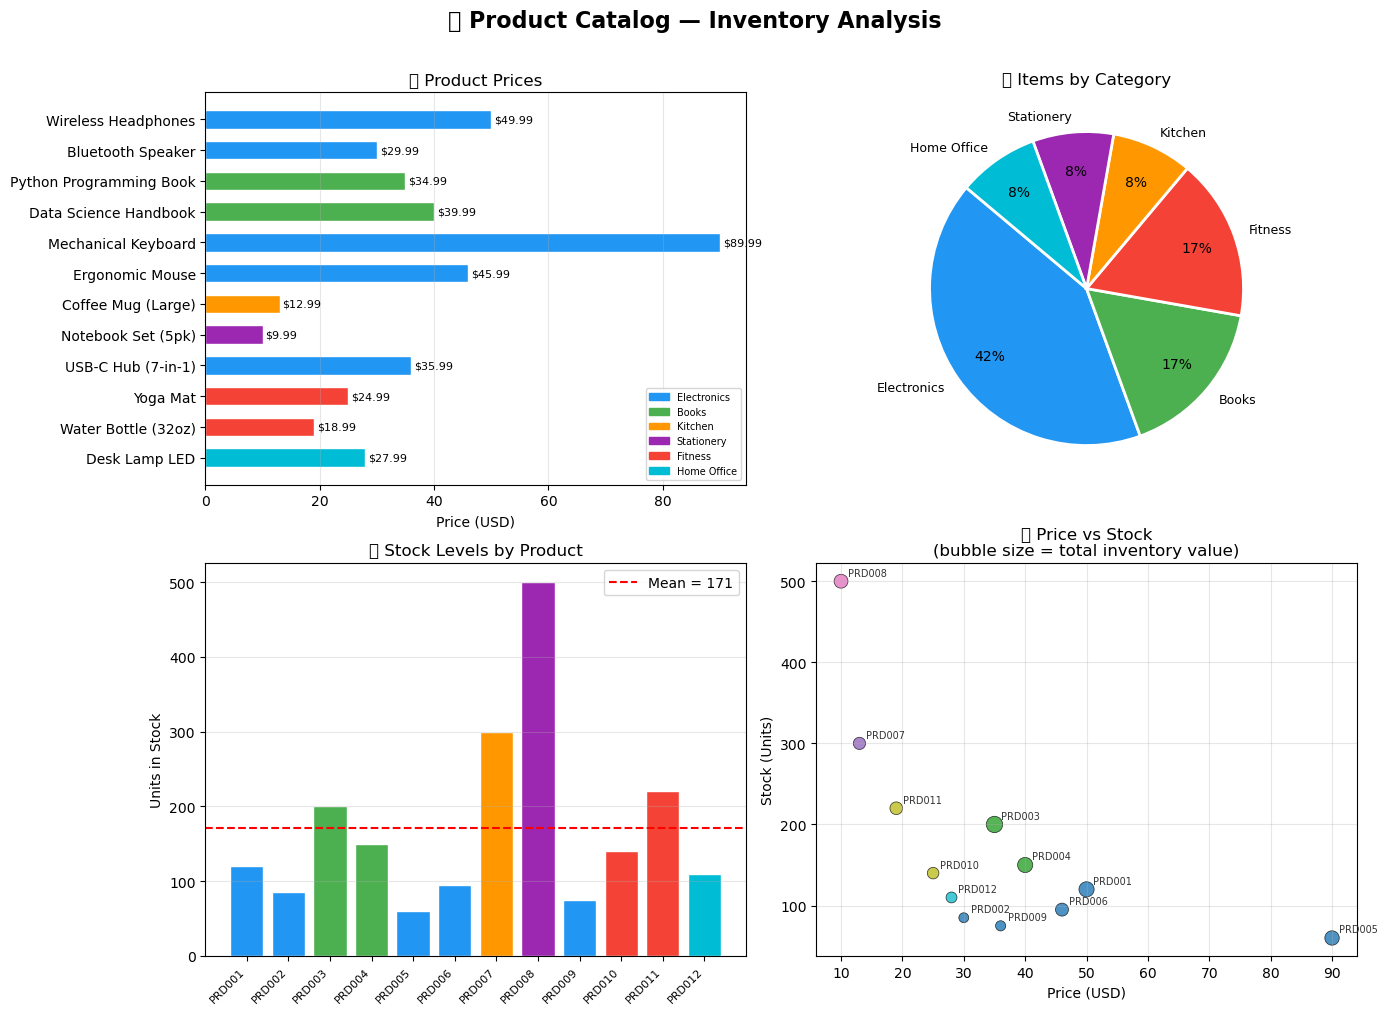

✅ Visualization saved as 'catalog_analysis.png'


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('🏷️ Product Catalog — Inventory Analysis', fontsize=16, fontweight='bold', y=1.01)

cat_colors = {
    'Electronics':'#2196F3','Books':'#4CAF50','Kitchen':'#FF9800',
    'Stationery':'#9C27B0','Fitness':'#F44336','Home Office':'#00BCD4'
}
colors_list = [cat_colors[c] for c in df['Category']]

# ── 1. Price by Product (horizontal bar)
ax1 = axes[0, 0]
bars = ax1.barh(df['Name'], df['Price'],
                color=[cat_colors[c] for c in df['Category']], edgecolor='white', height=0.6)
ax1.set_xlabel('Price (USD)')
ax1.set_title('💰 Product Prices')
ax1.invert_yaxis()
for bar in bars:
    ax1.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
             f'${bar.get_width():.2f}', va='center', fontsize=8)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in cat_colors.items() if k in df['Category'].values]
ax1.legend(handles=legend_patches, fontsize=7, loc='lower right')
ax1.grid(True, axis='x', alpha=0.3)

# ── 2. Category distribution (pie)
ax2 = axes[0, 1]
cat_counts = df['Category'].value_counts()
wedge_colors = [cat_colors[c] for c in cat_counts.index]
wedges, texts, autotexts = ax2.pie(
    cat_counts.values, labels=cat_counts.index,
    colors=wedge_colors, autopct='%1.0f%%',
    startangle=140, pctdistance=0.75,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
for t in texts: t.set_fontsize(9)
ax2.set_title('📁 Items by Category')

# ── 3. Stock levels (bar)
ax3 = axes[1, 0]
ax3.bar(range(len(df)), df['Stock'],
        color=[cat_colors[c] for c in df['Category']], edgecolor='white')
ax3.set_xticks(range(len(df)))
ax3.set_xticklabels(df['ProductID'], rotation=45, ha='right', fontsize=8)
ax3.set_ylabel('Units in Stock')
ax3.set_title('📦 Stock Levels by Product')
ax3.axhline(df['Stock'].mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {df["Stock"].mean():.0f}')
ax3.legend()
ax3.grid(True, axis='y', alpha=0.3)

# ── 4. Price vs Stock scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(df['Price'], df['Stock'],
                      c=[list(cat_colors.keys()).index(c) for c in df['Category']],
                      cmap='tab10', s=df['TotalValue']/50, alpha=0.8,
                      edgecolors='black', linewidths=0.5)
for _, row in df.iterrows():
    ax4.annotate(row['ProductID'], (row['Price'], row['Stock']),
                 textcoords='offset points', xytext=(5,4), fontsize=7, color='#333')
ax4.set_xlabel('Price (USD)')
ax4.set_ylabel('Stock (Units)')
ax4.set_title('💲 Price vs Stock\n(bubble size = total inventory value)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('catalog_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Visualization saved as 'catalog_analysis.png'")

## Step 5: Barcode Generation Functions

We define helper functions using the `barcode` library:
- `barcode.get()` — get the barcode object for a given format
- `barcode.get_barcode_class()` — get the appropriate barcode class
- `barcode.save()` — save the barcode as an image

In [7]:
# Create output directory
os.makedirs('barcodes', exist_ok=True)

def generate_barcode(product_id, product_name, price, save_dir='barcodes'):
    """
    Generate a Code128 barcode for a product and save as PNG.
    
    Args:
        product_id  : str — unique product identifier (e.g. 'PRD001')
        product_name: str — product display name
        price       : float — product price
        save_dir    : str — folder to save barcode images
    
    Returns:
        filepath: str — path to saved barcode PNG
    """
    # Step 1: Get the barcode class for Code128 format
    BarcodeClass = barcode.get_barcode_class('code128')
    
    # Step 2: Create the barcode object with the product ID as data
    barcode_obj = BarcodeClass(product_id, writer=ImageWriter())
    
    # Step 3: Configure writer options
    options = {
        'module_height': 10.0,
        'module_width': 0.4,
        'quiet_zone': 4.0,
        'font_size': 8,
        'text_distance': 3.0,
        'write_text': True,
        'background': 'white',
        'foreground': 'black',
    }
    
    # Step 4: Save the barcode as an image
    filepath = os.path.join(save_dir, product_id)
    barcode_obj.save(filepath, options=options)
    
    return filepath + '.png'


def generate_ean13_barcode(ean_code, product_name, save_dir='barcodes'):
    """
    Generate an EAN-13 barcode (standard retail format, 12 digits + check digit).
    
    Args:
        ean_code    : str — 12-digit EAN number (check digit auto-computed)
        product_name: str — product name for filename
        save_dir    : str — folder to save images
    
    Returns:
        filepath: str — path to saved barcode PNG
    """
    # Get EAN-13 barcode class
    EAN13Class = barcode.get_barcode_class('ean13')
    
    # Create EAN-13 barcode object
    ean_obj = EAN13Class(ean_code, writer=ImageWriter())
    
    options = {
        'module_height': 15.0,
        'module_width': 0.3,
        'quiet_zone': 6.5,
        'font_size': 9,
        'write_text': True,
    }
    
    safe_name = product_name.replace(' ', '_').replace('/', '-')
    filepath = os.path.join(save_dir, f'EAN_{safe_name}')
    ean_obj.save(filepath, options=options)
    
    return filepath + '.png'


print("✅ Barcode generation functions defined.")
print("   Supported barcode formats:", barcode.PROVIDED_BARCODES)

✅ Barcode generation functions defined.
   Supported barcode formats: ['codabar', 'code128', 'code39', 'ean', 'ean13', 'ean13-guard', 'ean14', 'ean8', 'ean8-guard', 'gs1', 'gs1_128', 'gtin', 'isbn', 'isbn10', 'isbn13', 'issn', 'itf', 'jan', 'nw-7', 'pzn', 'upc', 'upca']


## Step 6: Generate Barcodes for All Products

In [8]:
print("🔄 Generating Code128 barcodes for all products...")
print("-" * 55)

barcode_paths = []

for _, row in df.iterrows():
    try:
        path = generate_barcode(
            product_id   = row['ProductID'],
            product_name = row['Name'],
            price        = row['Price']
        )
        barcode_paths.append(path)
        status = "✅"
    except Exception as e:
        barcode_paths.append(None)
        status = f"❌ Error: {e}"
    
    print(f"  {status}  {row['ProductID']} — {row['Name'][:30]}")

df['BarcodePath'] = barcode_paths

generated = df['BarcodePath'].notna().sum()
print(f"\n✅ {generated}/{len(df)} barcodes generated in ./barcodes/")

🔄 Generating Code128 barcodes for all products...
-------------------------------------------------------
  ✅  PRD001 — Wireless Headphones
  ✅  PRD002 — Bluetooth Speaker
  ✅  PRD003 — Python Programming Book
  ✅  PRD004 — Data Science Handbook
  ✅  PRD005 — Mechanical Keyboard
  ✅  PRD006 — Ergonomic Mouse
  ✅  PRD007 — Coffee Mug (Large)
  ✅  PRD008 — Notebook Set (5pk)
  ✅  PRD009 — USB-C Hub (7-in-1)
  ✅  PRD010 — Yoga Mat
  ✅  PRD011 — Water Bottle (32oz)
  ✅  PRD012 — Desk Lamp LED

✅ 12/12 barcodes generated in ./barcodes/


## Step 7: Generate EAN-13 Barcodes (Standard Retail Format)

In [9]:
# Assign 12-digit EAN codes to first 6 products
ean_products = [
    ("690123000001", "Wireless Headphones"),
    ("690123000002", "Bluetooth Speaker"),
    ("690123000003", "Python Programming Book"),
    ("690123000004", "Data Science Handbook"),
    ("690123000005", "Mechanical Keyboard"),
    ("690123000006", "Ergonomic Mouse"),
]

print("🔄 Generating EAN-13 barcodes...")
ean_paths = []

for ean_code, name in ean_products:
    try:
        path = generate_ean13_barcode(ean_code, name)
        ean_paths.append((name, ean_code, path))
        print(f"  ✅  EAN-13 [{ean_code}] — {name}")
    except Exception as e:
        ean_paths.append((name, ean_code, None))
        print(f"  ❌  EAN-13 [{ean_code}] — {name}: {e}")

print(f"\n✅ EAN-13 barcodes saved in ./barcodes/")

🔄 Generating EAN-13 barcodes...
  ✅  EAN-13 [690123000001] — Wireless Headphones
  ✅  EAN-13 [690123000002] — Bluetooth Speaker
  ✅  EAN-13 [690123000003] — Python Programming Book
  ✅  EAN-13 [690123000004] — Data Science Handbook
  ✅  EAN-13 [690123000005] — Mechanical Keyboard
  ✅  EAN-13 [690123000006] — Ergonomic Mouse

✅ EAN-13 barcodes saved in ./barcodes/


## Step 8: Display Barcode Gallery

C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2442737671.py:23: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2442737671.py:24: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  plt.savefig('barcode_gallery.png', dpi=120, bbox_inches='tight')
d:\Application\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127991 (\N{LABEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


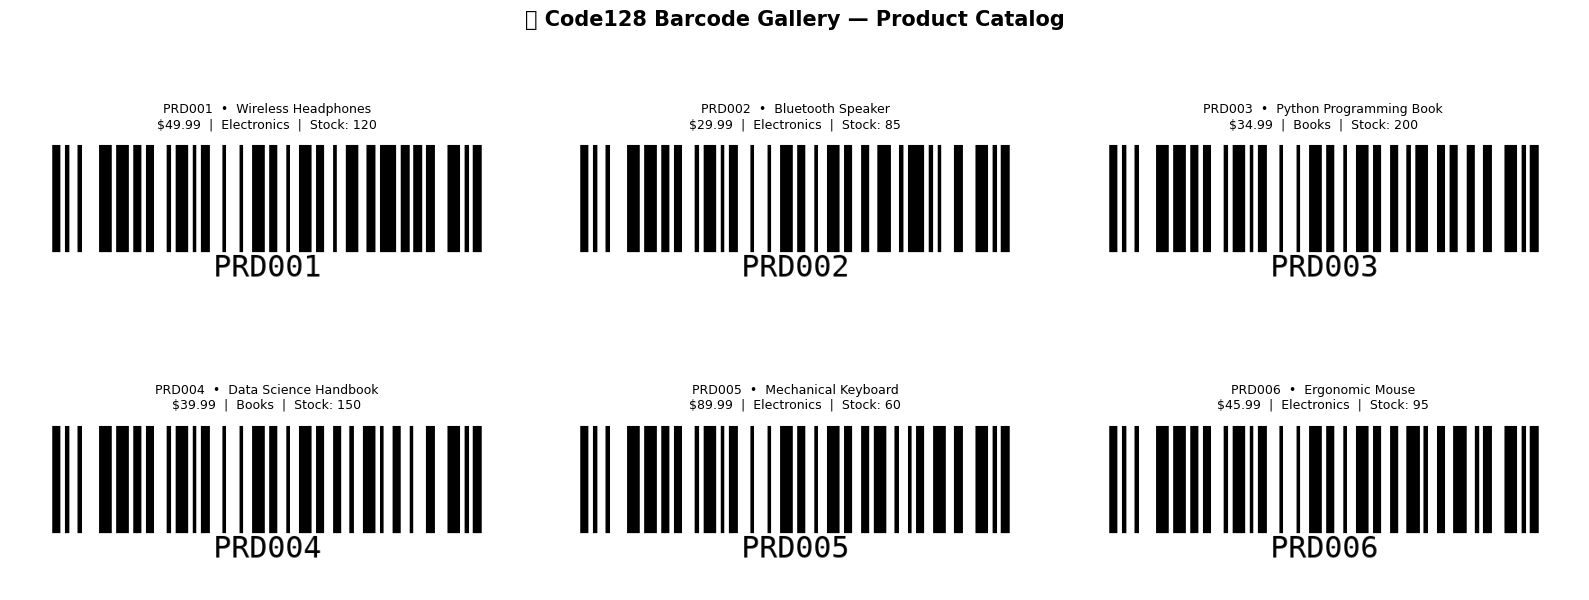

✅ Barcode gallery saved as 'barcode_gallery.png'


In [10]:
# ── Display the first 6 Code128 barcodes
valid = df[df['BarcodePath'].notna()].head(6)

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
fig.suptitle('🏷️ Code128 Barcode Gallery — Product Catalog', 
             fontsize=15, fontweight='bold')

for ax, (_, row) in zip(axes.flat, valid.iterrows()):
    try:
        img = mpimg.imread(row['BarcodePath'])
        ax.imshow(img, cmap='gray')
        ax.set_title(
            f"{row['ProductID']}  •  {row['Name']}\n"
            f"${row['Price']:.2f}  |  {row['Category']}  |  Stock: {row['Stock']}",
            fontsize=9, pad=6
        )
    except Exception as e:
        ax.text(0.5, 0.5, f'Image error\n{e}', ha='center', va='center',
                transform=ax.transAxes, color='red')
        ax.set_title(row['ProductID'])
    ax.axis('off')

plt.tight_layout()
plt.savefig('barcode_gallery.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Barcode gallery saved as 'barcode_gallery.png'")

C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2161213806.py:31: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\2161213806.py:32: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  plt.savefig('ean13_gallery.png', dpi=120, bbox_inches='tight')
d:\Application\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128722 (\N{SHOPPING TROLLEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


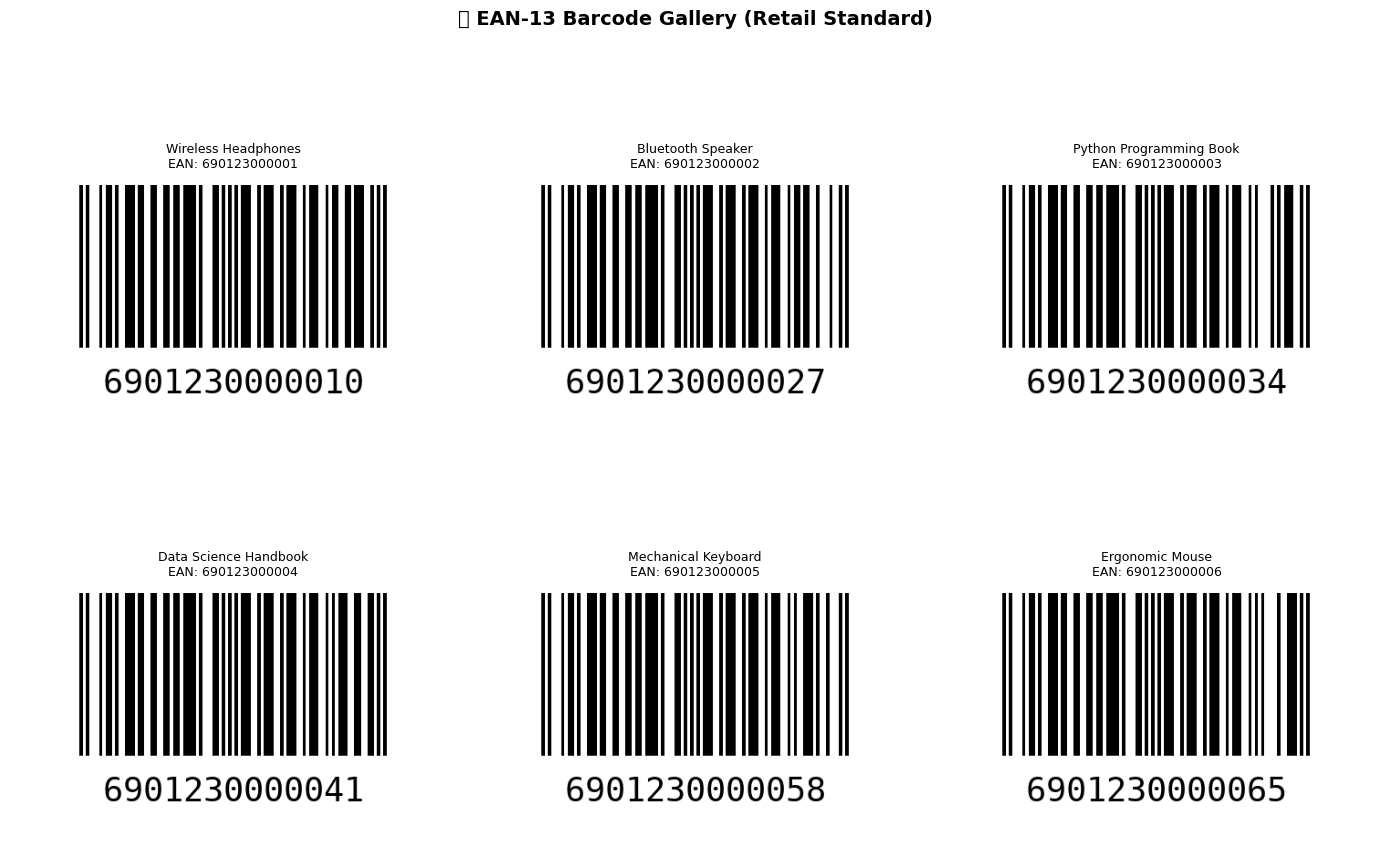

✅ EAN-13 gallery saved.


In [11]:
# ── Display EAN-13 barcodes
valid_ean = [(n, c, p) for n, c, p in ean_paths if p is not None]

if valid_ean:
    cols = min(3, len(valid_ean))
    rows = (len(valid_ean) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    
    fig.suptitle('🛒 EAN-13 Barcode Gallery (Retail Standard)',
                 fontsize=14, fontweight='bold')
    
    flat_axes = [ax for row_axes in axes for ax in (row_axes if hasattr(row_axes,'__iter__') else [row_axes])]
    
    for ax, (name, code, path) in zip(flat_axes, valid_ean):
        try:
            img = mpimg.imread(path)
            ax.imshow(img, cmap='gray')
            ax.set_title(f'{name}\nEAN: {code}', fontsize=9)
        except:
            ax.text(0.5, 0.5, 'Image error', ha='center', va='center',
                    transform=ax.transAxes, color='red')
        ax.axis('off')
    
    for ax in flat_axes[len(valid_ean):]:
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('ean13_gallery.png', dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ EAN-13 gallery saved.")
else:
    print("No valid EAN-13 images to display.")

## Step 9: Interactive Barcode Generator — Single Product Lookup

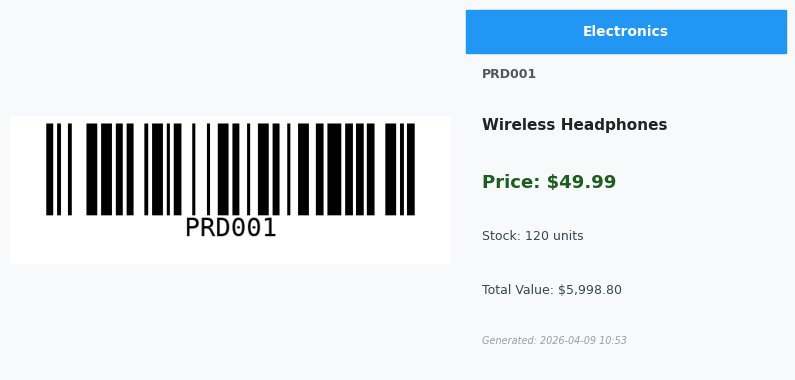

✅ Product label saved: barcodes/label_PRD001.png



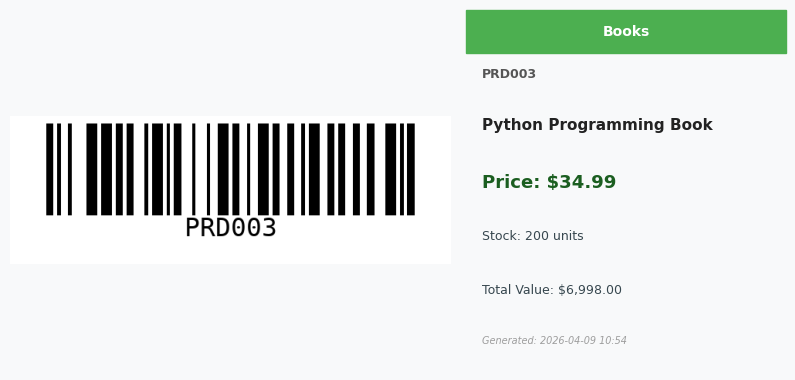

✅ Product label saved: barcodes/label_PRD003.png



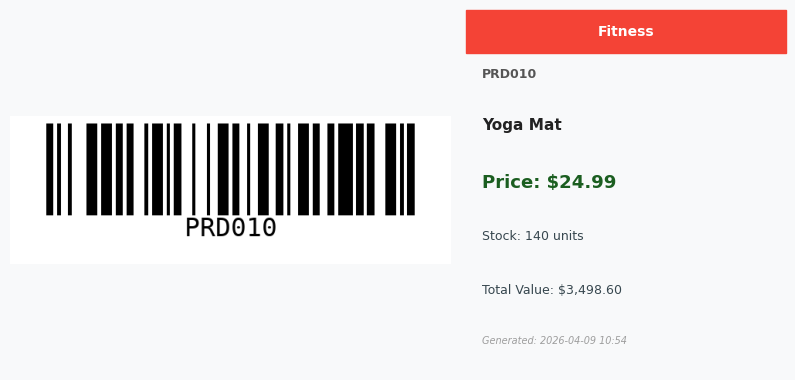

✅ Product label saved: barcodes/label_PRD010.png


In [12]:
def generate_product_label(product_id, catalog_df):
    """
    Full product label: barcode image + product info in a styled layout.
    """
    row = catalog_df[catalog_df['ProductID'] == product_id]
    if row.empty:
        print(f"❌ Product {product_id} not found in catalog.")
        return
    
    row = row.iloc[0]
    barcode_path = row['BarcodePath']
    
    if not barcode_path or not os.path.exists(barcode_path):
        print(f"❌ Barcode image not found for {product_id}. Regenerating...")
        barcode_path = generate_barcode(row['ProductID'], row['Name'], row['Price'])
    
    fig = plt.figure(figsize=(8, 4))
    fig.patch.set_facecolor('#F8F9FA')
    
    # Left panel: barcode image
    ax_bc = fig.add_axes([0.0, 0.0, 0.55, 1.0])
    try:
        img = mpimg.imread(barcode_path)
        ax_bc.imshow(img, cmap='gray')
    except:
        ax_bc.text(0.5, 0.5, 'Barcode\nimage\nnot available',
                   ha='center', va='center', transform=ax_bc.transAxes)
    ax_bc.axis('off')
    ax_bc.set_facecolor('white')
    
    # Right panel: product info
    ax_info = fig.add_axes([0.57, 0.05, 0.40, 0.90])
    ax_info.set_xlim(0, 1); ax_info.set_ylim(0, 1)
    ax_info.axis('off')
    ax_info.set_facecolor('#F8F9FA')
    
    cat_color = {
        'Electronics':'#2196F3','Books':'#4CAF50','Kitchen':'#FF9800',
        'Stationery':'#9C27B0','Fitness':'#F44336','Home Office':'#00BCD4'
    }.get(row['Category'], '#607D8B')
    
    ax_info.add_patch(plt.Rectangle((0,0.88), 1, 0.12, 
                                     color=cat_color, transform=ax_info.transAxes, clip_on=False))
    ax_info.text(0.5, 0.94, row['Category'], ha='center', va='center',
                 fontsize=10, fontweight='bold', color='white',
                 transform=ax_info.transAxes)
    
    info_lines = [
        (0.82, row['ProductID'],          '#555555', 9,  'bold'),
        (0.68, row['Name'],               '#222222', 11, 'bold'),
        (0.52, f"Price: ${row['Price']:.2f}", '#1B5E20', 13, 'bold'),
        (0.37, f"Stock: {row['Stock']} units",    '#37474F', 9,  'normal'),
        (0.22, f"Total Value: ${row['TotalValue']:,.2f}", '#37474F', 9, 'normal'),
        (0.08, f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}", '#9E9E9E', 7, 'italic'),
    ]
    
    for y, txt, col, fs, style in info_lines:
        weight = 'bold' if style == 'bold' else 'normal'
        ax_info.text(0.05, y, txt, color=col, fontsize=fs, fontweight=weight,
                     fontstyle='italic' if style=='italic' else 'normal',
                     transform=ax_info.transAxes, va='center')
    
    plt.savefig(f'barcodes/label_{product_id}.png', dpi=130, bbox_inches='tight',
                facecolor='#F8F9FA')
    plt.show()
    print(f"✅ Product label saved: barcodes/label_{product_id}.png")


# ── Generate labels for first 3 products
for pid in ['PRD001', 'PRD003', 'PRD010']:
    print(f"\n{'='*50}")
    generate_product_label(pid, df)

## Step 10: Barcode Batch Report

In [13]:
# ── Summary report of all generated barcodes
report = df[['ProductID','Name','Category','Price','Stock','TotalValue','BarcodePath']].copy()
report['BarcodeGenerated'] = report['BarcodePath'].apply(
    lambda p: '✅ Yes' if (p and os.path.exists(p)) else '❌ No'
)
report['FileSize_KB'] = report['BarcodePath'].apply(
    lambda p: round(os.path.getsize(p)/1024, 1) if (p and os.path.exists(p)) else 0
)

print("📋 Barcode Generation Report")
print("=" * 75)
display_cols = ['ProductID','Name','Price','BarcodeGenerated','FileSize_KB']
print(report[display_cols].to_string(index=False))

total_files = (report['BarcodeGenerated'] == '✅ Yes').sum()
total_size  = report['FileSize_KB'].sum()

print("\n" + "=" * 75)
print(f"  Total products       : {len(df)}")
print(f"  Barcodes generated   : {total_files}")
print(f"  Total file size      : {total_size:.1f} KB")
print(f"  Output folder        : ./barcodes/")
print(f"  Barcode format       : Code128")
print(f"  Additional EAN-13    : {len([p for _,_,p in ean_paths if p])} barcodes")

📋 Barcode Generation Report
ProductID                    Name  Price BarcodeGenerated  FileSize_KB
   PRD001     Wireless Headphones  49.99            ✅ Yes          2.9
   PRD002       Bluetooth Speaker  29.99            ✅ Yes          3.2
   PRD003 Python Programming Book  34.99            ✅ Yes          3.3
   PRD004   Data Science Handbook  39.99            ✅ Yes          3.1
   PRD005     Mechanical Keyboard  89.99            ✅ Yes          3.2
   PRD006         Ergonomic Mouse  45.99            ✅ Yes          3.4
   PRD007      Coffee Mug (Large)  12.99            ✅ Yes          3.1
   PRD008      Notebook Set (5pk)   9.99            ✅ Yes          3.4
   PRD009      USB-C Hub (7-in-1)  35.99            ✅ Yes          3.4
   PRD010                Yoga Mat  24.99            ✅ Yes          2.9
   PRD011     Water Bottle (32oz)  18.99            ✅ Yes          2.9
   PRD012           Desk Lamp LED  27.99            ✅ Yes          3.3

  Total products       : 12
  Barcodes generated

## Step 11: Results & Key Findings

C:\Users\hario\AppData\Local\Temp\ipykernel_8544\1496083526.py:32: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\1496083526.py:32: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\1496083526.py:32: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\1496083526.py:33: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.savefig('results_summary.png', dpi=120, bbox_inches='tight')
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\1496083526.py:33: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('results_summary.png', dpi=120, bbox_inches='tight')
C:\Users\hario\AppData\Local\Temp\ipykernel_8544\1496083526.py:33: UserWarning: Glyph 128202 (

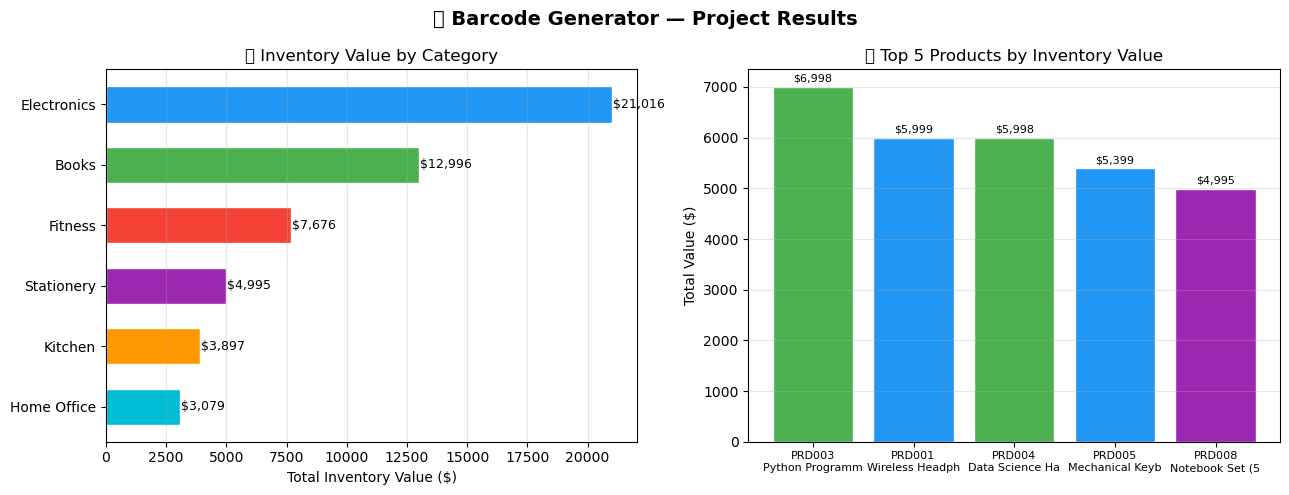

📌 KEY FINDINGS
  📦 Total Products         : 12
  🏷️  Barcodes Generated     : 12 (Code128) + 6 (EAN-13)
  💰 Total Inventory Value  : $53,659.45
  🏆 Highest Value Category : Electronics ($21,015.65)
  🥇 Most Valuable Product  : Python Programming Book ($6,998.00)
  💲 Most Affordable Item   : Notebook Set (5pk) ($9.99)
  📦 Highest Stock Item     : Notebook Set (5pk) (500 units)
  📁 Output Directory       : ./barcodes/


In [14]:
# Final summary visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('📊 Barcode Generator — Project Results', fontsize=14, fontweight='bold')

# Total inventory value by category
cat_val = df.groupby('Category')['TotalValue'].sum().sort_values(ascending=True)
bar_colors = [cat_colors.get(c,'gray') for c in cat_val.index]
bars = axes[0].barh(cat_val.index, cat_val.values, color=bar_colors, edgecolor='white', height=0.6)
axes[0].set_xlabel('Total Inventory Value ($)')
axes[0].set_title('💰 Inventory Value by Category')
for bar in bars:
    axes[0].text(bar.get_width()+50, bar.get_y()+bar.get_height()/2,
                 f'${bar.get_width():,.0f}', va='center', fontsize=9)
axes[0].grid(True, axis='x', alpha=0.3)

# Top 5 products by total value
top5 = df.nlargest(5, 'TotalValue')
bar_cols2 = [cat_colors.get(c,'gray') for c in top5['Category']]
bars2 = axes[1].bar(range(5), top5['TotalValue'], color=bar_cols2, edgecolor='white')
axes[1].set_xticks(range(5))
axes[1].set_xticklabels(
    [f"{row['ProductID']}\n{row['Name'][:15]}" for _, row in top5.iterrows()],
    fontsize=8
)
axes[1].set_ylabel('Total Value ($)')
axes[1].set_title('🏆 Top 5 Products by Inventory Value')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+100,
                 f'${bar.get_height():,.0f}', ha='center', fontsize=8)
axes[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results_summary.png', dpi=120, bbox_inches='tight')
plt.show()

print("=" * 55)
print("📌 KEY FINDINGS")
print("=" * 55)
most_val_cat = cat_val.idxmax()
most_val_prod = df.loc[df['TotalValue'].idxmax()]
cheapest = df.loc[df['Price'].idxmin()]
most_stock = df.loc[df['Stock'].idxmax()]

print(f"  📦 Total Products         : {len(df)}")
print(f"  🏷️  Barcodes Generated     : {total_files} (Code128) + {len([p for _,_,p in ean_paths if p])} (EAN-13)")
print(f"  💰 Total Inventory Value  : ${df['TotalValue'].sum():,.2f}")
print(f"  🏆 Highest Value Category : {most_val_cat} (${cat_val[most_val_cat]:,.2f})")
print(f"  🥇 Most Valuable Product  : {most_val_prod['Name']} (${most_val_prod['TotalValue']:,.2f})")
print(f"  💲 Most Affordable Item   : {cheapest['Name']} (${cheapest['Price']})")
print(f"  📦 Highest Stock Item     : {most_stock['Name']} ({most_stock['Stock']} units)")
print(f"  📁 Output Directory       : ./barcodes/")

## Conclusion

This **Barcode Generator** project successfully demonstrated:

1. **Data Setup** — Created a realistic 12-product inventory with ID, name, price, category, and stock.

2. **EDA & Visualization** — Explored price distributions, category breakdowns, stock levels, and inventory value using Matplotlib.

3. **Barcode Generation** — Used the `python-barcode` library to:
   - Generate **Code128** barcodes (alphanumeric product IDs)
   - Generate **EAN-13** barcodes (standard 13-digit retail format)
   - Save all barcodes as PNG images using `barcode.save()`

4. **Product Labels** — Combined barcode images with product metadata into styled product labels.

5. **Batch Report** — Generated a summary report of all barcodes with file sizes.

**Real-world applications:**
- Retail inventory management systems
- Library book cataloging
- Warehouse logistics
- Event ticketing
- Asset tracking

---
✅ **Fun Project — Barcode Generator Complete!**